Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together. This is from 22-23 season, feel free to update to 2023-24 season if you want.
# Data Sources:

https://www.basketball-reference.com/leagues/NBA_2024_totals.html # reference for performance data
https://www.basketball-reference.com/contracts/players.html # reference for salary data


Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


# Clustering Lab

In [87]:
#Drop variables that will not be needed or are duplicates
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import get_dummies
performance = pd.read_csv('../data/NBA_Perf_22.csv',encoding='latin1')
performance["Player"] = performance["Player"].str.replace("?", "ć")
salary = pd.read_csv('../data/nba_salaries_22.csv',encoding='utf-8-sig',engine='python')

In [88]:
#calculate PER
performance['PER']= (performance['FG']*85.910+performance['STL']*53.897+performance['3P']*51.757+performance['FT']*46.845+performance['BLK']*39.190+performance['ORB']*39.190+performance['DRB']*14.707+performance['AST']*34.677-(performance['FGA']-performance['FG'])*39.190-(performance['FTA']-performance['FT'])*20.091-performance['TOV']*53.897-performance['PF']*17.174)*(1/performance['MP'])
performance['PER'] = performance['PER'].round(2)
#performance['PER'] = performance['PER'].replace([np.inf, -np.inf], np.nan)
#performance['PER'] = performance['PER'].fillna(0)
performance['PER'] = performance['PER'].astype(float)

count    812.000000
mean      14.545443
std        8.550377
min      -46.540000
25%       10.970000
50%       14.945000
75%       18.875000
max       85.910000
Name: PER, dtype: float64


{'whiskers': [<matplotlib.lines.Line2D at 0xffff35ab7a70>,
 'caps': [<matplotlib.lines.Line2D at 0xffff35ab6840>,
 'boxes': [<matplotlib.lines.Line2D at 0xffff35ab76b0>],
 'medians': [<matplotlib.lines.Line2D at 0xffff35ab7bf0>],
 'fliers': [<matplotlib.lines.Line2D at 0xffff35ab57f0>],
 'means': []}

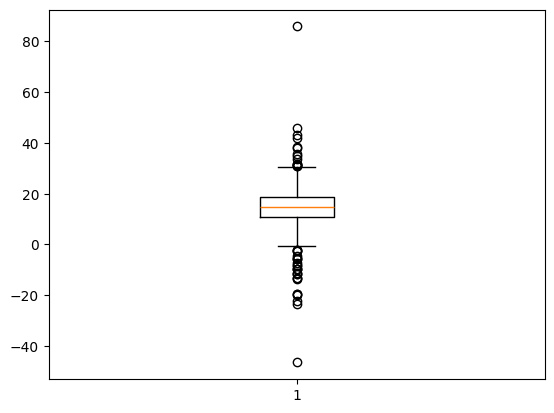

In [89]:
#EDA
print(performance['PER'].describe())
plt.boxplot(performance['PER'])

In [90]:
#Categorizing for different positions
PG = performance[performance['Pos'] == 'PG']
SG = performance[performance['Pos'] == 'SG']
SF = performance[performance['Pos'] == 'SF']
PF = performance[performance['Pos'] == 'PF']
CE = performance[performance['Pos'] == 'C']
#Creating five separate dataframes for each position
#Excluding players who don't really play
def minutes_played(df):
    df = df[df['MP'] > 10]
    return df
PG = minutes_played(PG)
SG = minutes_played(SG)
SF = minutes_played(SF)
PF = minutes_played(PF)
CE = minutes_played(CE)

In [91]:
PG.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 10 to 808
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  126 non-null    object 
 1   Pos     126 non-null    object 
 2   Age     126 non-null    int64  
 3   Tm      126 non-null    object 
 4   G       126 non-null    int64  
 5   GS      126 non-null    int64  
 6   MP      126 non-null    float64
 7   FG      126 non-null    float64
 8   FGA     126 non-null    float64
 9   FG%     126 non-null    float64
 10  3P      126 non-null    float64
 11  3PA     126 non-null    float64
 12  3P%     125 non-null    float64
 13  2P      126 non-null    float64
 14  2PA     126 non-null    float64
 15  2P%     126 non-null    float64
 16  eFG%    126 non-null    float64
 17  FT      126 non-null    float64
 18  FTA     126 non-null    float64
 19  FT%     119 non-null    float64
 20  ORB     126 non-null    float64
 21  DRB     126 non-null    float64
 22  TRB   

In [92]:
def clustering(df):
    df['Label'] = df.apply(lambda x: 
        'Good' if x['PER'] > 20 
        else 'Mid' if 10 <= x['PER'] <= 20 
        else 'Bad',
        axis=1
    )
    return df
PG = clustering(PG)

In [93]:
#Clustering
clust_data_PG = pd.get_dummies(PG['Label'])  # or PG['Label'] if that's the name
#PG.groupby("PER").agg({"Good": "sum", "Mid": "sum", "Bad": "sum"})
kmeans_obj_PG = KMeans(n_clusters=2, random_state=1).fit(clust_data_PG)

#Run the clustering algo with your best guess for K

In [94]:
#View the results
print(kmeans_obj_PG.cluster_centers_) #the result is a 2*3 matrix, each row representing a coordinate, which means 2 clusters with 3 features


[[5.51020408e-01 4.48979592e-01 4.44089210e-16]
 [2.49800181e-16 1.94289029e-16 1.00000000e+00]]


In [96]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
fig = px.scatter_3d(PG['Label'], x="Good", y="Mid", z="Bad", color=kmeans_obj_PG.labels_,
                    title="Aye vs. Nay vs. Other votes for Democrat-introduced bills")
fig.show(renderer="browser")

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Label'] but received: Good

In [97]:
PG['Label'].head()

10    Mid
18    Mid
22    Mid
23    Mid
24    Mid
Name: Label, dtype: object

In [ ]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

In [ ]:
#Visualize the results of the elbow method

In [ ]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results

In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Use the model to select players for Mr. Rooney to consider

#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.